In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Load Dataset and Initial Exploration

First, we'll use `pandas` to load the dataset. Please **replace `'/content/your_dataset.csv'` with the actual path to your dataset file**.

After loading, we'll perform the requested initial exploration steps, including displaying the first 5 rows, shape, column names, data types, and missing values. If you intend to use GPU acceleration for subsequent data processing (e.g., with `cuDF`), we can explore that once the data is loaded.

In [4]:
import pandas as pd

# IMPORTANT: Replace '/content/your_dataset.csv' with the actual path to your dataset file
try:
    df = pd.read_csv('/content/screen_time_app_usage_dataset.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Dataset file not found. Please upload your dataset or provide the correct path.")
    df = None # Set df to None if loading fails


Dataset loaded successfully!


In [5]:
if df is not None:
    print("\n1. First 5 rows of the dataset:")
    display(df.head())

    print("\n2. Shape of the dataset (rows, columns):")
    print(df.shape)

    print("\n3. Column names:")
    print(df.columns.tolist())

    print("\n4. Data types of each column:")
    print(df.info())

    print("\n5. Missing values in each column:")
    print(df.isnull().sum())


1. First 5 rows of the dataset:


,user_id,date,app_name,category,screen_time_min,launches,interactions,is_productive,youtube_views,youtube_likes,...,extra_col_14,extra_col_15,extra_col_16,extra_col_17,extra_col_18,extra_col_19,extra_col_20,extra_col_21,extra_col_22,extra_col_23
0,1051,2024-01-01 00:00:00.000000000,Camera,Utilities,24.53,2,7,False,NaN,NaN,...,33.43,49.03,64.74,49.49,47.64,38.34,39.56,49.14,62.18,55.91
1,1088,2024-01-01 00:43:41.673891297,Chrome,Utilities,19.78,3,2,False,NaN,NaN,...,44.06,49.40,66.63,62.10,47.64,51.88,42.35,55.86,45.96,46.69
2,1052,2024-01-01 01:27:23.347782594,Spotify,Entertainment,32.03,1,6,False,NaN,NaN,...,55.18,41.87,54.84,65.59,61.28,49.51,41.11,55.53,44.13,71.01
3,1028,2024-01-01 02:11:05.021673891,Google Maps,Utilities,19.10,2,5,False,NaN,NaN,...,59.39,47.87,54.68,56.14,63.98,46.75,46.98,40.15,48.11,50.09
4,1034,2024-01-01 02:54:46.695565188,Instagram,Social,25.19,1,5,False,NaN,NaN,...,51.58,60.38,51.23,44.38,52.71,58.19,37.47,55.64,51.60,37.37



2. Shape of the dataset (rows, columns):
(3000, 24)

3. Column names:
['user_id', 'date', 'app_name', 'category', 'screen_time_min', 'launches', 'interactions', 'is_productive', 'youtube_views', 'youtube_likes', 'youtube_comments', 'extra_col_11', 'extra_col_12', 'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16', 'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20', 'extra_col_21', 'extra_col_22', 'extra_col_23']

4. Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           3000 non-null   int64  
 1   date              3000 non-null   object 
 2   app_name          3000 non-null   object 
 3   category          3000 non-null   object 
 4   screen_time_min   3000 non-null   float64
 5   launches          3000 non-null   int64  
 6   interactions      3000 non-null   int64 

Auto Analyze Columns


### Automated Data Analysis and Feature Recommendations

Based on the dataset's structure and common data science practices, I'll perform an automated analysis to:

1.  **Identify and convert the 'date' column:** Ensuring it's in the correct datetime format for time-series analysis.
2.  **Suggest a target column:** For future predictive modeling, based on the dataset's context.
3.  **List numerical columns:** These are typically used directly in many models or require scaling.
4.  **List categorical columns:** These often require encoding (e.g., one-hot encoding, label encoding) before use in models.
5.  **Recommend best features:** Considering their relevance, completeness (lack of missing values), and potential predictive power.

In [6]:
if df is not None:
    print("--- Automated Data Analysis ---")

    # 1. Date/Time Column Identification and Conversion
    date_column = 'date'
    if date_column in df.columns and df[date_column].dtype == 'object':
        df[date_column] = pd.to_datetime(df[date_column])
        print(f"\n1. Converted '{date_column}' to datetime type.")
    else:
        print(f"\n1. '{date_column}' not found or already datetime type.")

    # 2. Target Column for Future Prediction
    # Based on the dataset name 'screen_time_app_usage_dataset', 'screen_time_min' is a strong candidate.
    target_column = 'screen_time_min'
    if target_column in df.columns:
        print(f"\n2. Recommended target column for future prediction: '{target_column}' (to predict screen time usage).")
    else:
        print(f"\n2. Could not automatically identify a clear target column. Consider 'screen_time_min', 'launches', or 'interactions'.")

    # 3. Numerical Columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"\n3. Numerical columns: {numerical_cols}")

    # 4. Categorical Columns
    categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
    print(f"\n4. Categorical columns: {categorical_cols}")

    # 5. Best Features to Use Recommendations
    print("\n5. Best Features Recommendations:")
    recommended_features = []

    # Add non-null relevant numerical features
    for col in numerical_cols:
        if col not in [target_column] and df[col].isnull().sum() == 0:
            recommended_features.append(col)

    # Add non-null relevant categorical features
    for col in categorical_cols:
        if col not in [date_column] and df[col].isnull().sum() == 0:
            # Exclude high cardinality columns or those that are less relevant
            if df[col].nunique() < 500 or col in ['app_name', 'category']:
                 recommended_features.append(col)

    print("   - Highly recommended features (low missing values, direct relevance): ", recommended_features)

    # Consider 'user_id' as a feature if you plan to do per-user analysis
    if 'user_id' in df.columns:
        print("   - 'user_id' can be used as a categorical feature for per-user analysis or embedding.")

    # Columns with many missing values might need imputation or be excluded
    missing_value_cols = df.isnull().sum()
    high_missing_cols = missing_value_cols[missing_value_cols > 0].index.tolist()
    if high_missing_cols:
        print(f"   - Columns with significant missing values ({high_missing_cols}) may require careful imputation or feature engineering if used.")

    # The 'extra_col' columns might be synthetic and need further domain-specific evaluation
    extra_cols = [col for col in df.columns if 'extra_col' in col]
    if extra_cols:
        print(f"   - 'Extra_col' columns ({extra_cols}) might be synthetic or placeholders; evaluate their relevance and distribution carefully.")

    print("\n--- Analysis Complete ---")

--- Automated Data Analysis ---

1. Converted 'date' to datetime type.

2. Recommended target column for future prediction: 'screen_time_min' (to predict screen time usage).

3. Numerical columns: ['user_id', 'screen_time_min', 'launches', 'interactions', 'youtube_views', 'youtube_likes', 'youtube_comments', 'extra_col_11', 'extra_col_12', 'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16', 'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20', 'extra_col_21', 'extra_col_22', 'extra_col_23']

4. Categorical columns: ['app_name', 'category', 'is_productive']

5. Best Features Recommendations:
   - Highly recommended features (low missing values, direct relevance):  ['user_id', 'launches', 'interactions', 'extra_col_11', 'extra_col_12', 'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16', 'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20', 'extra_col_21', 'extra_col_22', 'extra_col_23', 'app_name', 'category', 'is_productive']
   - 'user_id' ca

perfomring EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

### 1. Correlation Heatmap

This heatmap will show the correlation between different numerical features in the dataset. A strong positive correlation (close to 1) indicates that as one variable increases, the other also increases. A strong negative correlation (close to -1) indicates that as one variable increases, the other decreases. Values close to 0 suggest a weak or no linear relationship.

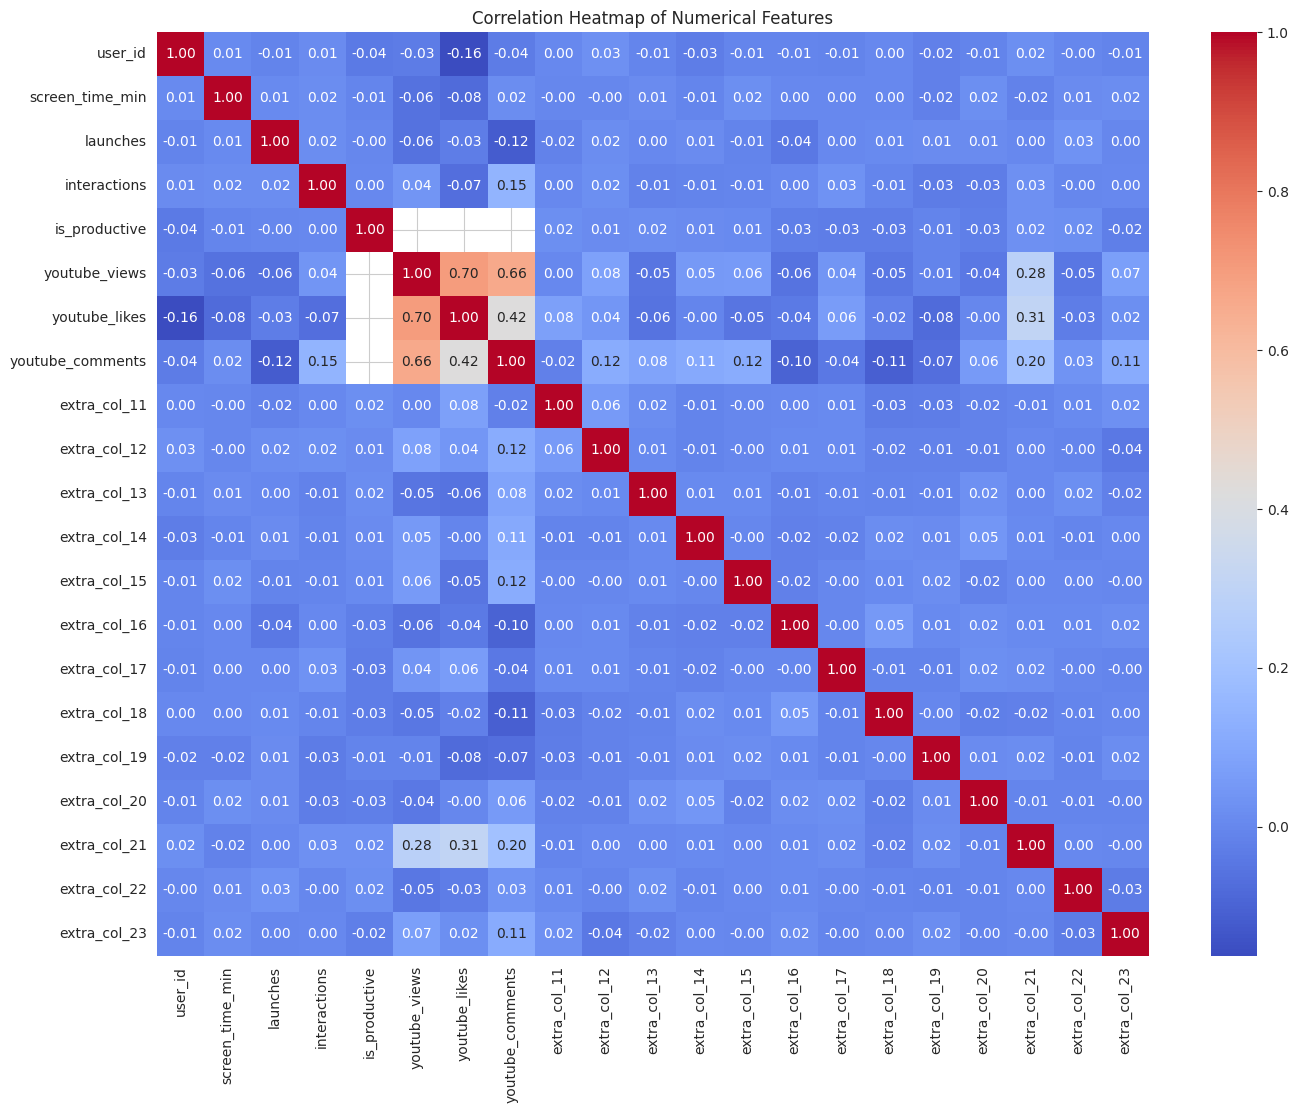

In [8]:
if df is not None:
    # Select only numerical columns for correlation calculation
    # Exclude user_id if it's treated as an identifier and not a numerical feature for correlation
    numerical_df = df.select_dtypes(include=['int64', 'float64', 'bool'])

    # Drop columns with all NaN values as they would result in NaN correlations
    numerical_df = numerical_df.dropna(axis=1, how='all')

    if not numerical_df.empty:
        plt.figure(figsize=(16, 12))
        sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Heatmap of Numerical Features')
        plt.show()
    else:
        print("No numerical columns available for correlation heatmap after cleaning.")

### 2. Histograms of Numerical Features

Histograms are useful for visualizing the distribution of numerical data. They help us understand the frequency of different value ranges within a column, identify potential skewness, and detect multi-modal distributions.

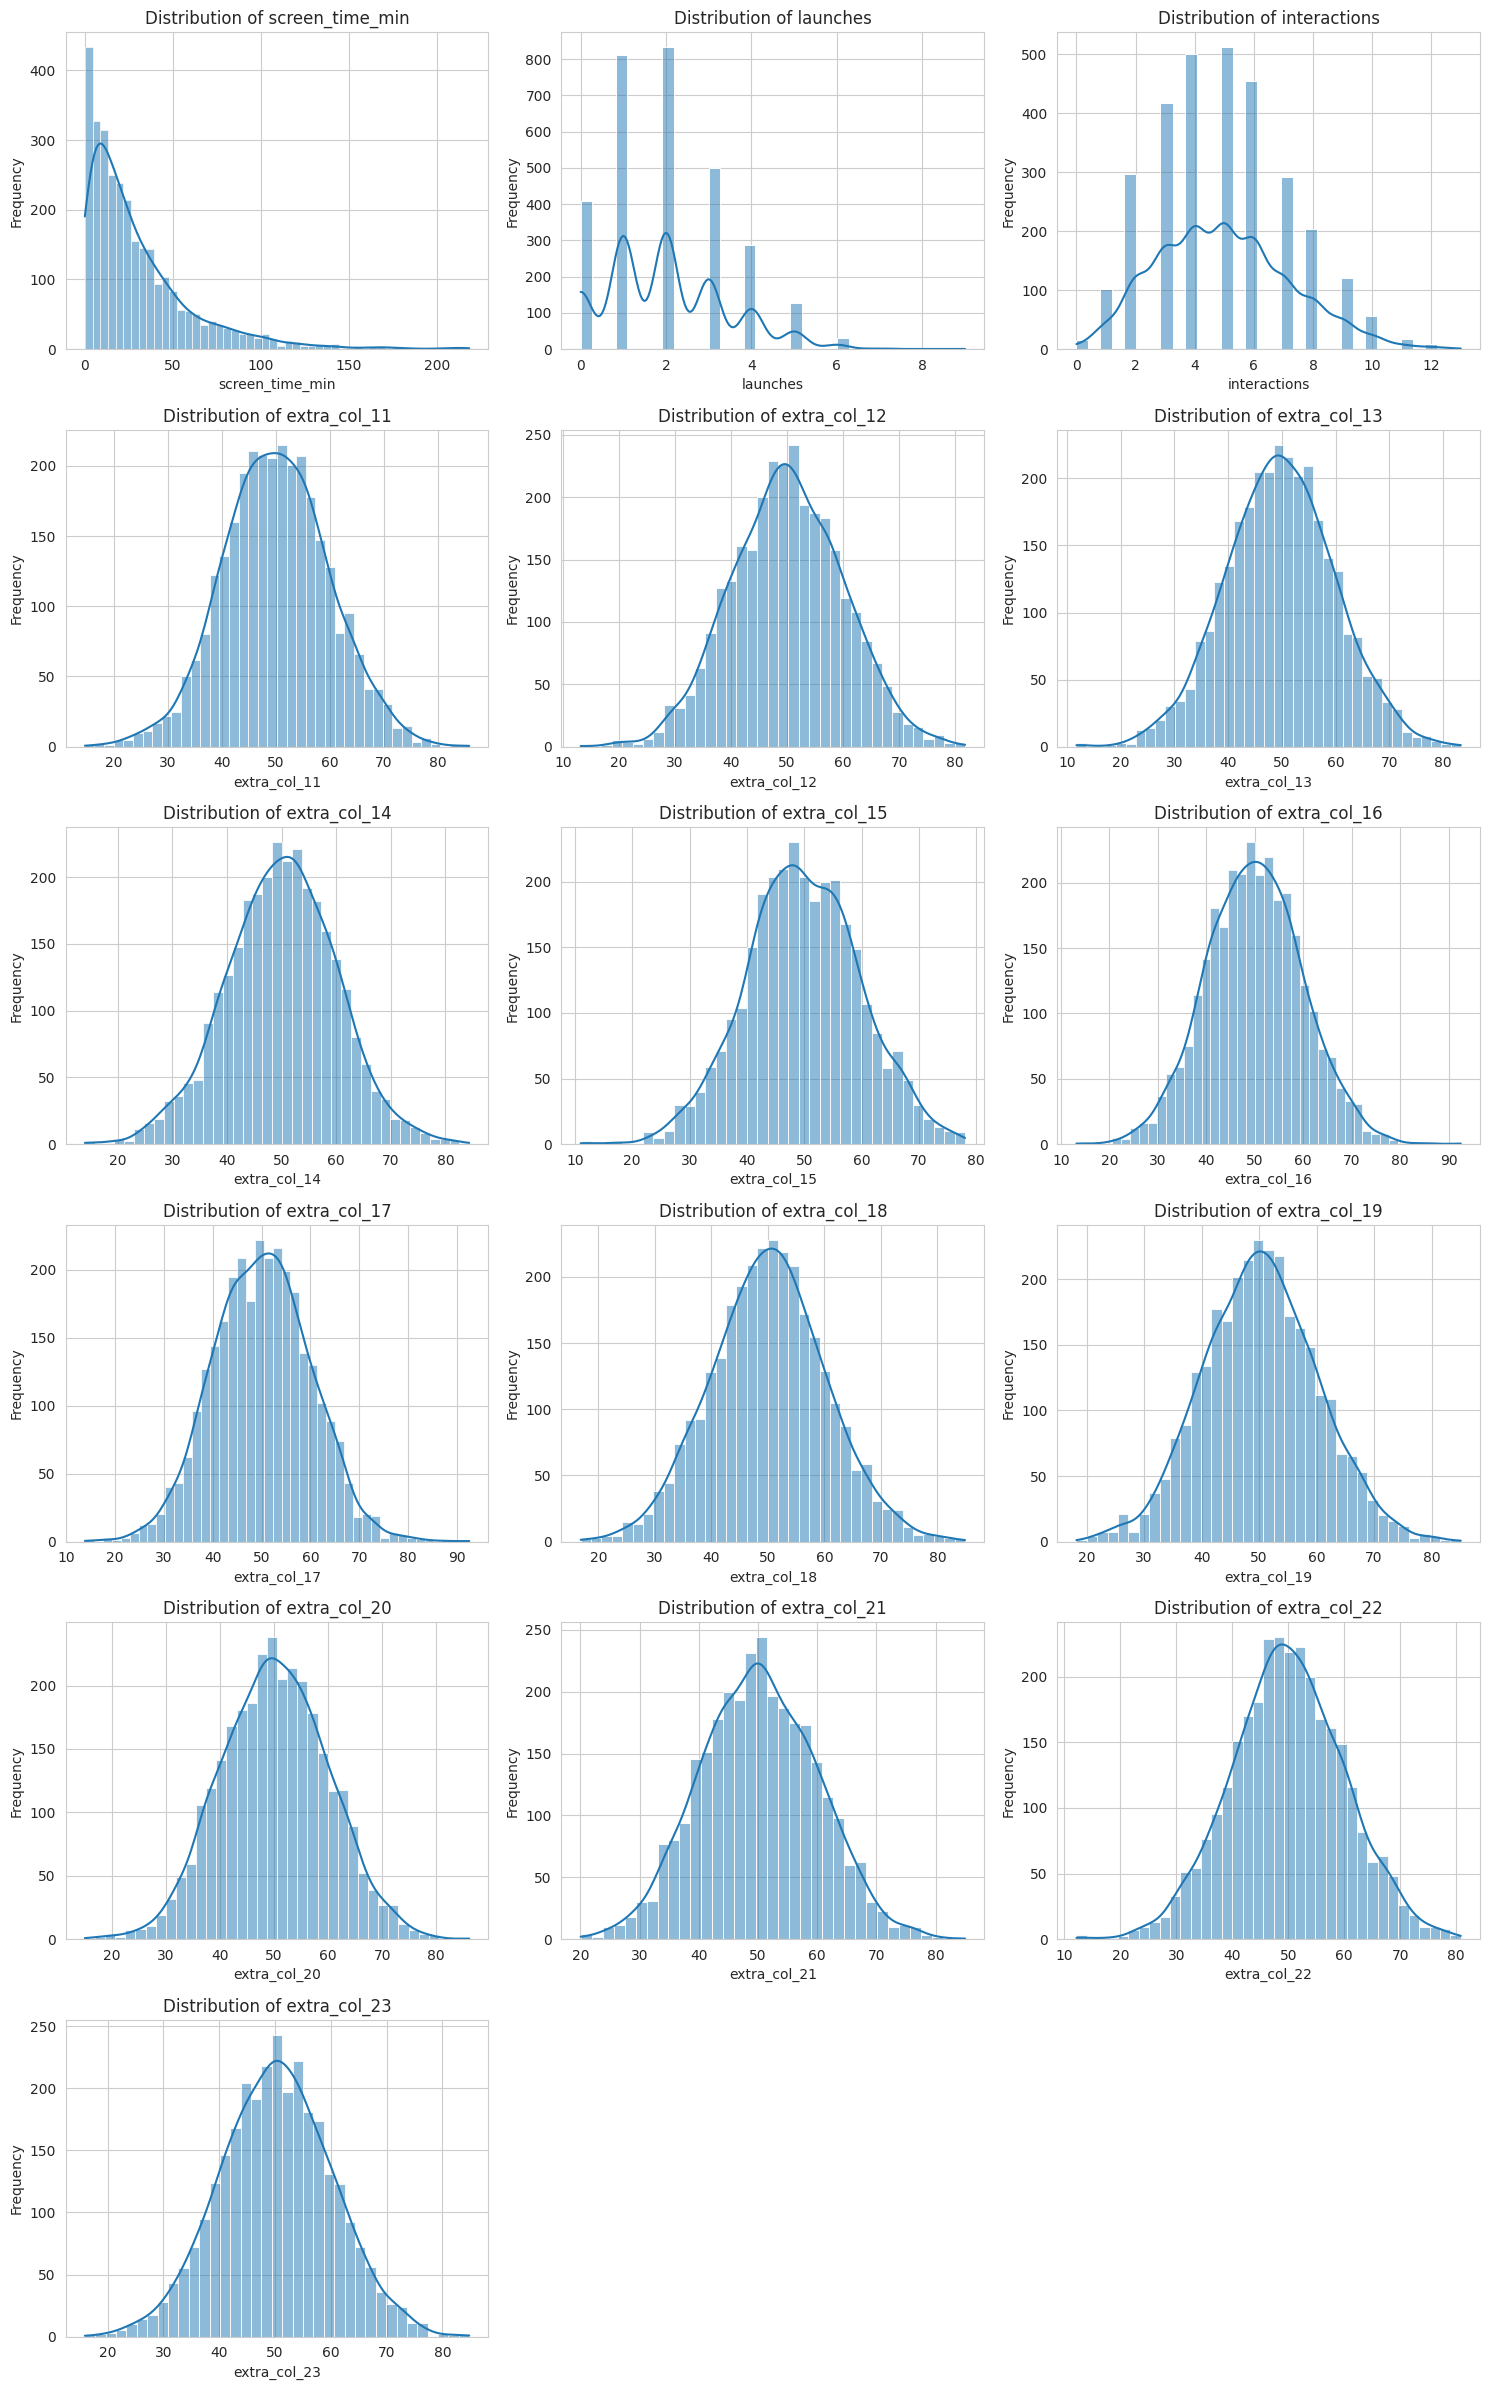

In [9]:
if df is not None:
    # Get numerical columns, excluding those with many unique values like user_id if not meaningful for histogram
    # and also columns with many missing values as they might skew the plot
    numerical_cols_for_hist = [col for col in numerical_cols if col not in ['user_id'] and df[col].nunique() > 1 and df[col].isnull().sum() < len(df) * 0.5]

    if numerical_cols_for_hist:
        # Adjust the number of rows/columns based on the number of numerical features
        n_cols = 3
        n_rows = (len(numerical_cols_for_hist) + n_cols - 1) // n_cols

        plt.figure(figsize=(n_cols * 5, n_rows * 4))
        for i, col in enumerate(numerical_cols_for_hist):
            plt.subplot(n_rows, n_cols, i + 1)
            sns.histplot(df[col].dropna(), kde=True)
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print("No suitable numerical columns for histograms.")

### 3. Screen Time Trend Over Time

This line plot will visualize how `screen_time_min` changes over time, aggregated by day. This helps identify any temporal patterns, such as daily fluctuations or long-term trends.

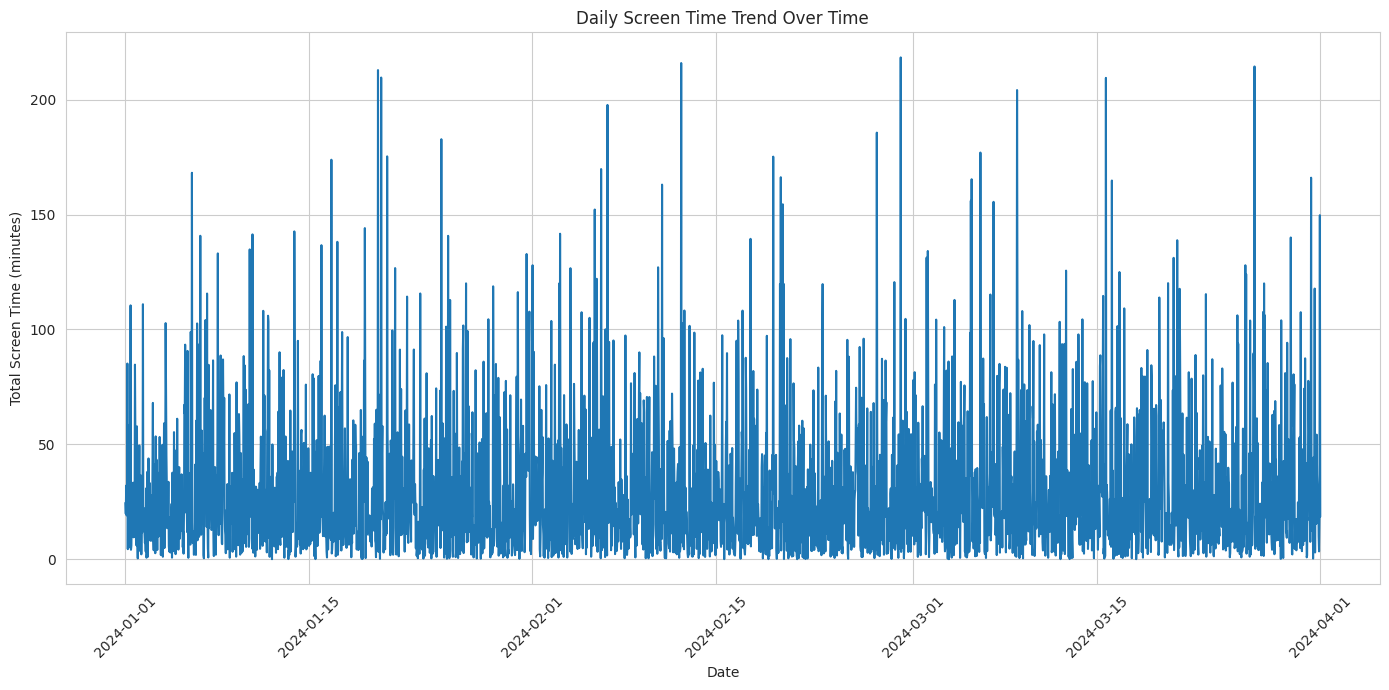

In [10]:
if df is not None and 'date' in df.columns and 'screen_time_min' in df.columns:
    # Aggregate screen time by date
    daily_screen_time = df.groupby('date')['screen_time_min'].sum().reset_index()

    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='screen_time_min', data=daily_screen_time)
    plt.title('Daily Screen Time Trend Over Time')
    plt.xlabel('Date')
    plt.ylabel('Total Screen Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("'date' or 'screen_time_min' column not found for time series analysis.")

### 4. Top App Categories by Usage

This bar chart will display the total screen time for the top app categories. It helps to understand which types of applications consume the most screen time.

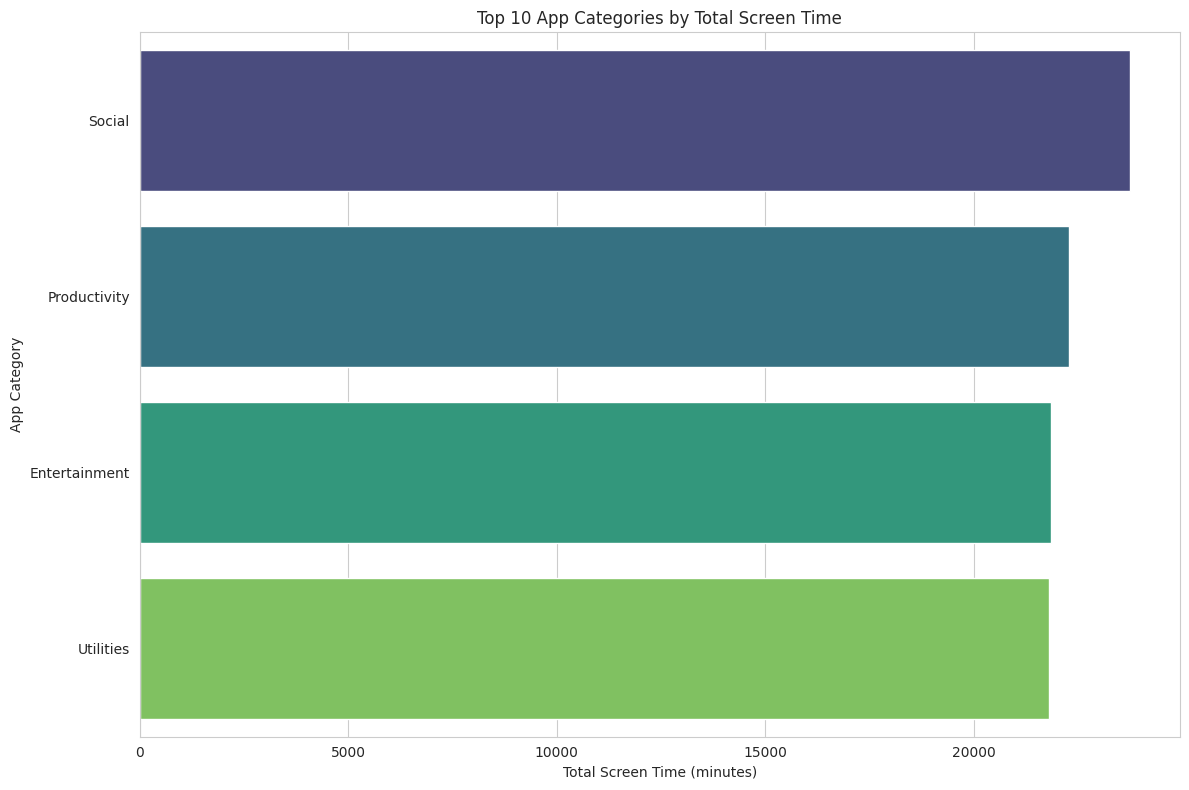

In [13]:
if df is not None and 'category' in df.columns and 'screen_time_min' in df.columns:
    # Aggregate screen time by app category
    category_screen_time = df.groupby('category')['screen_time_min'].sum().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(12, 8))
    sns.barplot(x='screen_time_min', y='category', data=category_screen_time.head(10), palette='viridis', hue='category', legend=False) # Show top 10 categories
    plt.title('Top 10 App Categories by Total Screen Time')
    plt.xlabel('Total Screen Time (minutes)')
    plt.ylabel('App Category')
    plt.tight_layout()
    plt.show()
else:
    print("'category' or 'screen_time_min' column not found for app category analysis.")

### 5. Boxplots for Outliers in Numerical Features

Boxplots are effective for visualizing the distribution of numerical data and identifying potential outliers. Outliers are data points that significantly differ from other observations, and they can indicate variability in measurement, experimental errors, or a novelty.

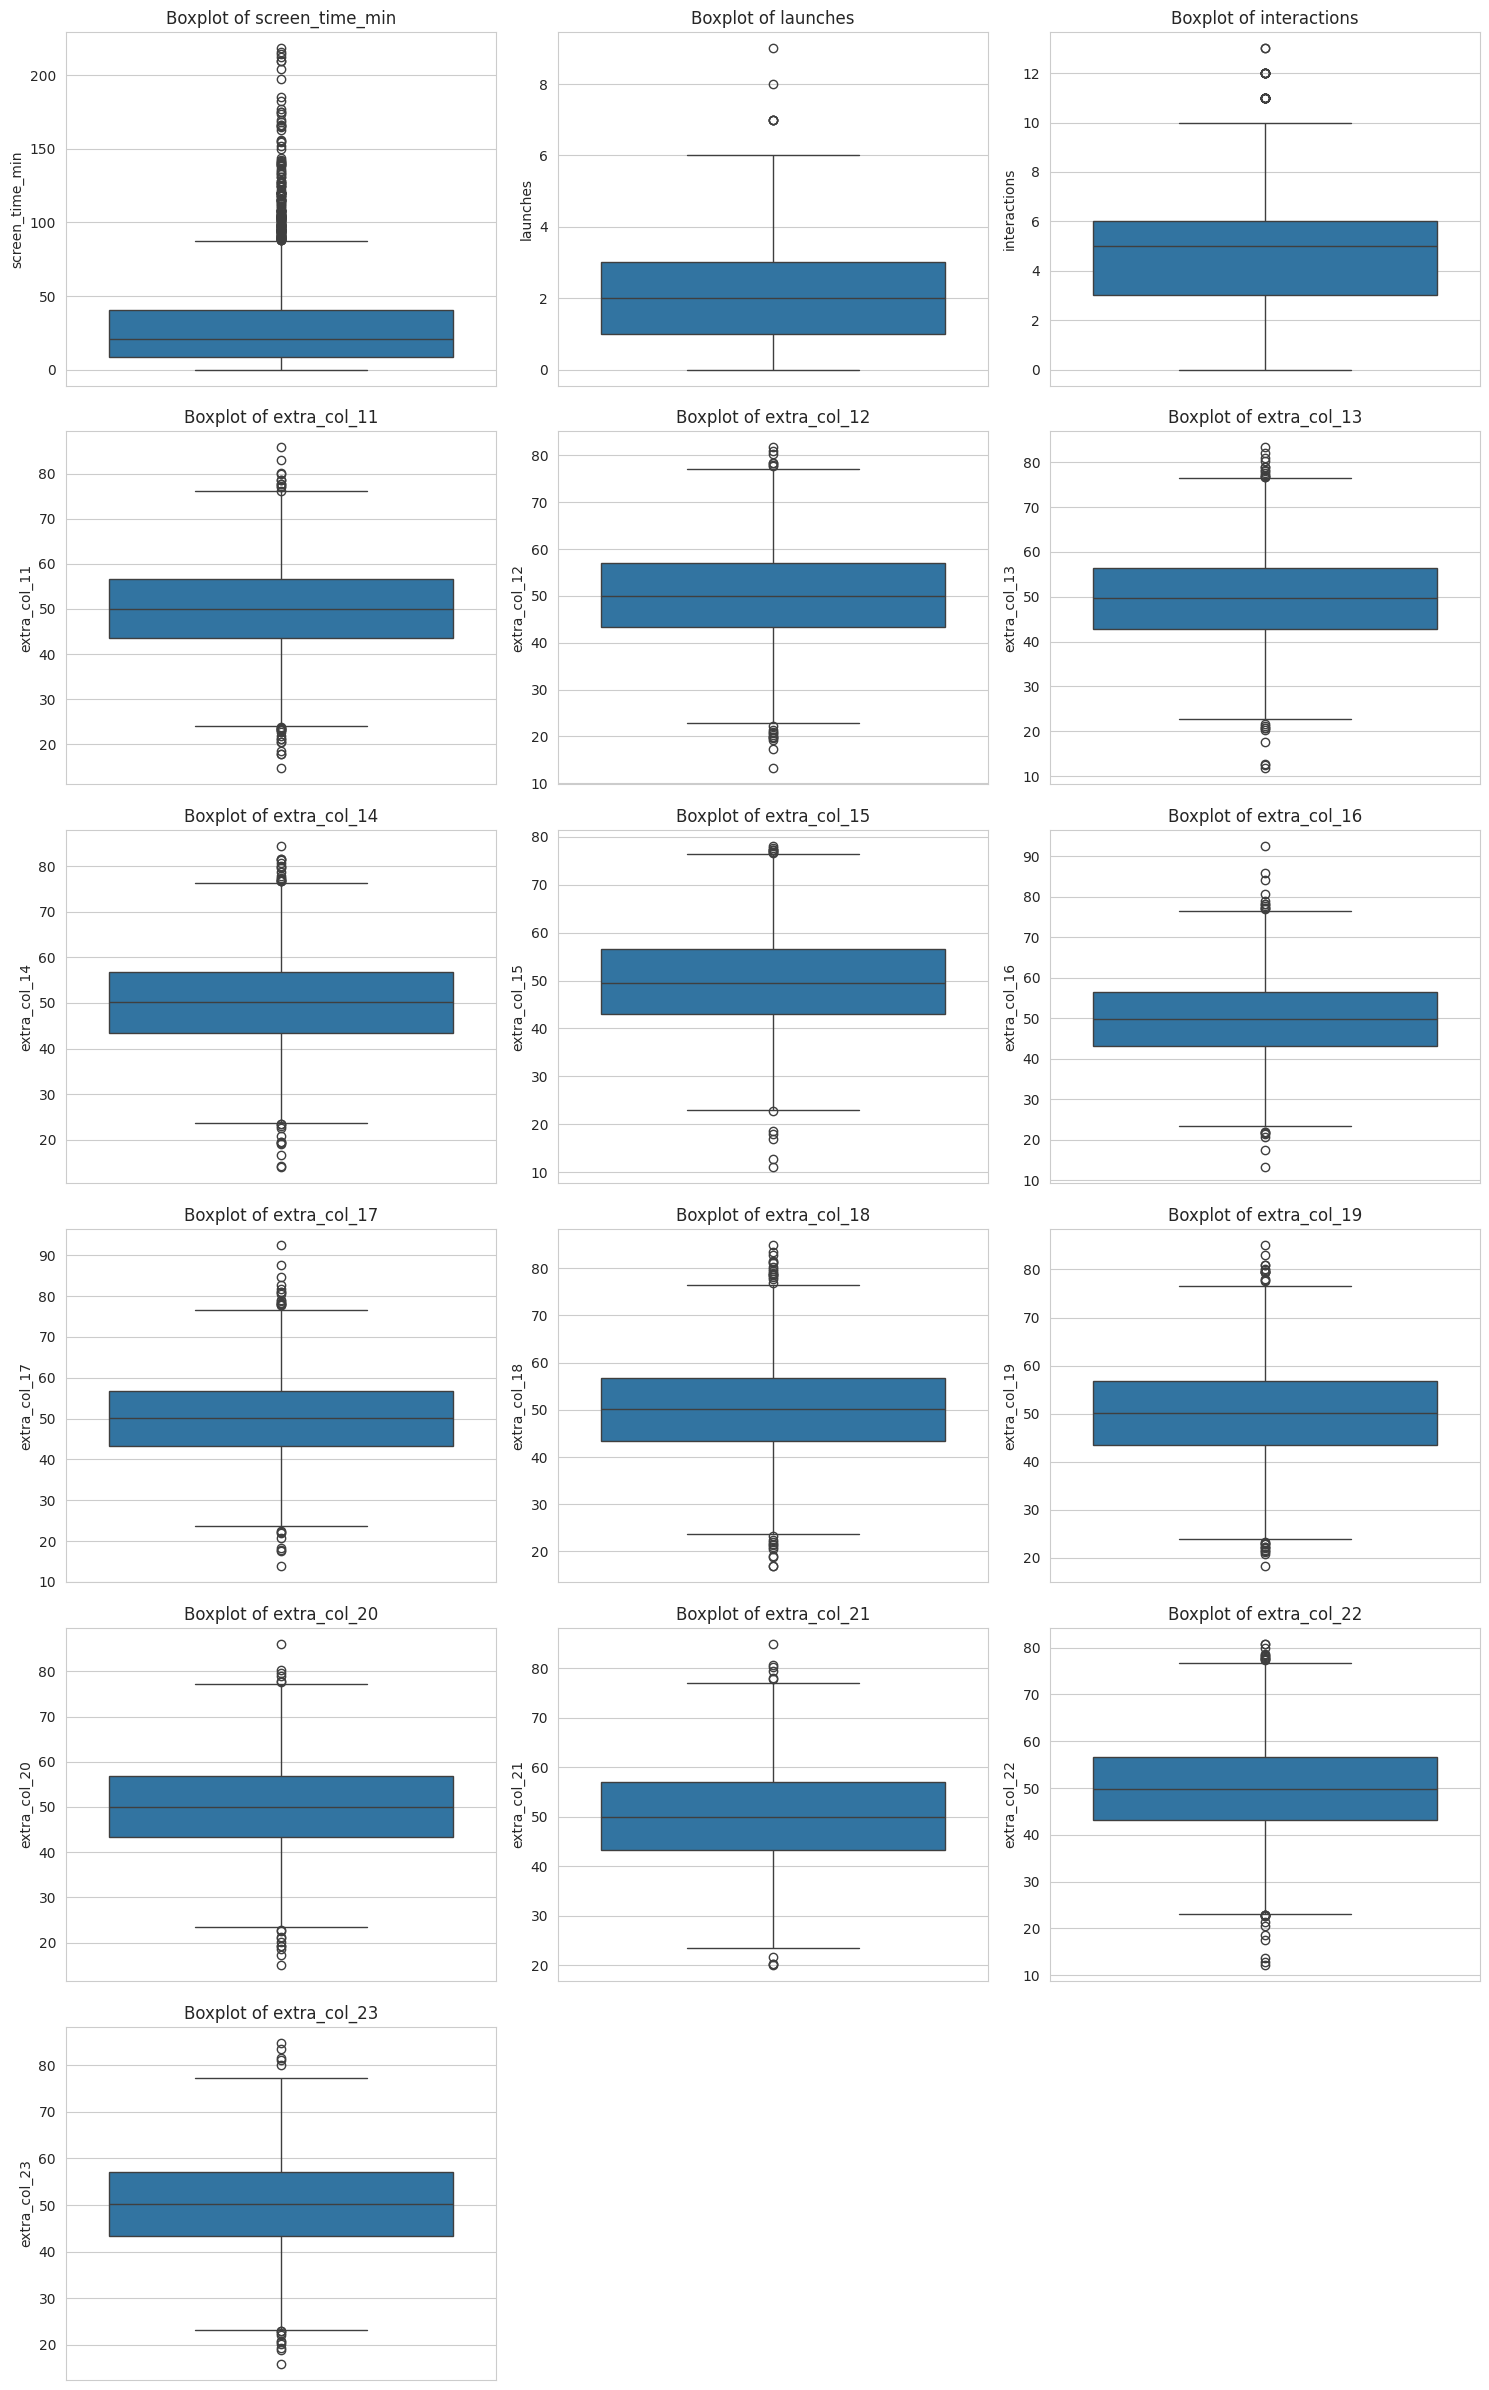

In [12]:
if df is not None:
    # Get numerical columns for boxplots, excluding user_id and those with too many missing values
    numerical_cols_for_boxplot = [col for col in numerical_cols if col not in ['user_id'] and df[col].isnull().sum() < len(df) * 0.5]

    if numerical_cols_for_boxplot:
        n_cols = 3
        n_rows = (len(numerical_cols_for_boxplot) + n_cols - 1) // n_cols

        plt.figure(figsize=(n_cols * 5, n_rows * 4))
        for i, col in enumerate(numerical_cols_for_boxplot):
            plt.subplot(n_rows, n_cols, i + 1)
            sns.boxplot(y=df[col].dropna())
            plt.title(f'Boxplot of {col}')
            plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print("No suitable numerical columns for boxplots.")

Data Preprocessing


In [14]:
from sklearn.preprocessing import MinMaxScaler

if df is not None:
    print("--- Data Preprocessing ---")

    # 1. Date column is already converted to datetime type in previous steps.
    # We'll just ensure it's sorted.
    df = df.sort_values(by='date').reset_index(drop=True)
    print("\n1. Dataset sorted by 'date'.")

    # 2. Fill missing values (specifically for youtube_ columns)
    # These columns are typically relevant only for YouTube app usage.
    # Filling with 0 makes sense if the app is not YouTube and thus has no views/likes/comments.
    youtube_cols = ['youtube_views', 'youtube_likes', 'youtube_comments']
    for col in youtube_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
            print(f"   - Filled missing values in '{col}' with 0.")

    # Identify numerical and categorical columns for preprocessing
    # Exclude the target column and user_id from features for now if not directly encoded.
    target_column = 'screen_time_min'
    # Exclude 'user_id' from direct one-hot encoding if it's meant to be an identifier or treated differently
    features_df = df.drop(columns=[target_column, 'date'], errors='ignore')

    # Separate numerical and categorical features
    numerical_features_to_scale = features_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features_to_encode = features_df.select_dtypes(include=['object', 'bool']).columns.tolist()

    # Ensure 'is_productive' is treated as categorical for encoding, if it's boolean
    if 'is_productive' in categorical_features_to_encode and df['is_productive'].dtype == 'bool':
        df['is_productive'] = df['is_productive'].astype(int) # Convert bool to int (0/1) for scaling or simple models
        if 'is_productive' in numerical_features_to_scale:
            numerical_features_to_scale.remove('is_productive') # remove it to encode it manually or use as is


    print(f"\n3. Identified numerical features for scaling: {numerical_features_to_scale}")
    print(f"4. Identified categorical features for one-hot encoding: {categorical_features_to_encode}")

    # 4. One-hot encode categorical columns
    if categorical_features_to_encode:
        df = pd.get_dummies(df, columns=categorical_features_to_encode, drop_first=True)
        print("\n5. Categorical columns one-hot encoded.")
    else:
        print("\n5. No categorical columns to one-hot encode.")

    # Re-identify numerical columns after one-hot encoding, for scaling.
    # This list will now include the new dummy variables.
    # Exclude target and date again.
    columns_for_scaling = df.drop(columns=[target_column, 'date', 'user_id'], errors='ignore').select_dtypes(include=['int64', 'float64']).columns.tolist()

    # 5. Scale numerical columns using MinMaxScaler
    if columns_for_scaling:
        scaler = MinMaxScaler()
        df[columns_for_scaling] = scaler.fit_transform(df[columns_for_scaling])
        print("\n6. Numerical columns scaled using MinMaxScaler.")
    else:
        print("\n6. No numerical columns to scale.")

    # 6. Prepare target column for future screen time prediction
    X = df.drop(columns=[target_column, 'date'], errors='ignore')
    y = df[target_column]
    print(f"\n7. Target column '{target_column}' separated (y). Features (X) prepared.")

    print("\n--- Preprocessing Complete ---")
    print("Shape of X (features):", X.shape)
    print("Shape of y (target):", y.shape)
    display(X.head())
    display(y.head())

--- Data Preprocessing ---

1. Dataset sorted by 'date'.
   - Filled missing values in 'youtube_views' with 0.
   - Filled missing values in 'youtube_likes' with 0.
   - Filled missing values in 'youtube_comments' with 0.

3. Identified numerical features for scaling: ['user_id', 'launches', 'interactions', 'youtube_views', 'youtube_likes', 'youtube_comments', 'extra_col_11', 'extra_col_12', 'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16', 'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20', 'extra_col_21', 'extra_col_22', 'extra_col_23']
4. Identified categorical features for one-hot encoding: ['app_name', 'category', 'is_productive']

5. Categorical columns one-hot encoded.

6. Numerical columns scaled using MinMaxScaler.

7. Target column 'screen_time_min' separated (y). Features (X) prepared.

--- Preprocessing Complete ---
Shape of X (features): (3000, 42)
Shape of y (target): (3000,)


,user_id,launches,interactions,youtube_views,youtube_likes,youtube_comments,extra_col_11,extra_col_12,extra_col_13,extra_col_14,...,app_name_TikTok,app_name_Twitch,app_name_Twitter,app_name_Weather,app_name_WhatsApp,app_name_YouTube,category_Productivity,category_Social,category_Utilities,is_productive_1
0,1051,0.222222,0.538462,0.0,0.0,0.0,0.455107,0.353799,0.607263,0.276587,...,False,False,False,False,False,False,False,False,True,False
1,1088,0.333333,0.153846,0.0,0.0,0.0,0.710552,0.537407,0.336173,0.427517,...,False,False,False,False,False,False,False,False,True,False
2,1052,0.111111,0.461538,0.0,0.0,0.0,0.452859,0.645472,0.641341,0.585404,...,False,False,False,False,False,False,False,False,False,False
3,1028,0.222222,0.384615,0.0,0.0,0.0,0.414500,0.527490,0.494413,0.645180,...,False,False,False,False,False,False,False,False,True,False
4,1034,0.111111,0.384615,0.0,0.0,0.0,0.475903,0.646201,0.478492,0.534289,...,False,False,False,False,False,False,False,True,False,False


,screen_time_min
0,24.53
1,19.78
2,32.03
3,19.10
4,25.19


Create Time-Series Sequences


### Create Sliding Window Sequences for Time Series Prediction

To prepare the data for time series forecasting, we will create sequences using a sliding window approach. This means for each prediction, we will use the data from the previous `n_steps` (in this case, 7) days as input features (`X_seq`) to predict the target value (`y_seq`) for the next day.

In [20]:
import numpy as np

def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - n_steps):
        # Use n_steps past observations as input (X)
        X_seq.append(X.iloc[i:(i + n_steps)].values)
        # The next observation as the target (y)
        y_seq.append(y.iloc[i + n_steps])
    return np.array(X_seq), np.array(y_seq)

# Define the number of past timesteps to use
n_steps = 7

if 'X' in locals() and 'y' in locals() and X is not None and y is not None:
    # Ensure X is entirely numerical (float) before creating sequences
    X_numeric = X.astype(float)

    X_seq, y_seq = create_sequences(X_numeric, y, n_steps)

    print(f"Created sequences using {n_steps} timesteps:")
    print("Shape of X_seq (features sequences):", X_seq.shape)
    print("Shape of y_seq (target sequences):", y_seq.shape)
else:
    print("X or y DataFrame not found. Please ensure preprocessing was completed successfully.")

Created sequences using 7 timesteps:
Shape of X_seq (features sequences): (2993, 7, 42)
Shape of y_seq (target sequences): (2993,)


Train Test Split


### Train-Test Split for Time Series Data

For time series data, it's essential to split the data chronologically to ensure that the training set precedes the test set. This maintains the temporal order and prevents data leakage from the future into the past. We'll use an 80/20 split, where the first 80% of the data will be for training, and the remaining 20% for testing, without shuffling.

In [21]:
if 'X_seq' in locals() and 'y_seq' in locals() and X_seq is not None and y_seq is not None:
    # Define the split ratio
    train_ratio = 0.8
    split_index = int(len(X_seq) * train_ratio)

    # Split the data without shuffling, preserving sequence order
    X_train, X_test = X_seq[:split_index], X_seq[split_index:]
    y_train, y_test = y_seq[:split_index], y_seq[split_index:]

    print("Train-Test Split Complete!")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("X_seq or y_seq not found. Please ensure time-series sequences were created successfully.")

Train-Test Split Complete!
X_train shape: (2394, 7, 42)
y_train shape: (2394,)
X_test shape: (599, 7, 42)
y_test shape: (599,)


LSTM Model

### Build and Train LSTM Model

We will now build a Long Short-Term Memory (LSTM) neural network using TensorFlow/Keras. LSTMs are particularly well-suited for time series forecasting tasks due to their ability to learn long-term dependencies.

The model will consist of:
- An LSTM layer with 64 units to capture temporal patterns.
- A Dropout layer to prevent overfitting.
- A Dense output layer for the final prediction.

We will compile the model using the Adam optimizer and Mean Squared Error (MSE) as the loss function, which is suitable for regression tasks. EarlyStopping will be used to monitor the validation loss and stop training if it doesn't improve after a certain number of epochs, further preventing overfitting.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the LSTM model
model = Sequential([
    LSTM(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Dropout layer for regularization
    Dense(units=1) # Output layer for a single regression value
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,457 (107.25 KB)

 Trainable params: 27,457 (107.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

We will train the LSTM model using the `X_train` and `y_train` data, and validate its performance on `X_test` and `y_test`. The training process will utilize the `early_stopping` callback to monitor the validation loss and prevent overfitting.

In [23]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 26514.5879 - val_loss: 1042.0536
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6949.3130 - val_loss: 981.3571
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4951.0444 - val_loss: 984.8298
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3518.7168 - val_loss: 993.8362
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2835.8984 - val_loss: 969.3676
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2265.0251 - val_loss: 974.3484
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1926.0227 - val_loss: 969.5381
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1795.6838 - val_loss: 994.8745
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1643.5040 - val_loss: 971.0803
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1456.9305 - val_loss: 977.8483
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1339.6448 - val_loss: 971.0753
Epoch

### Plot Training History

Visualizing the training history allows us to assess the model's learning progress and identify potential issues like overfitting or underfitting. We will plot both the training loss and validation loss over the epochs.

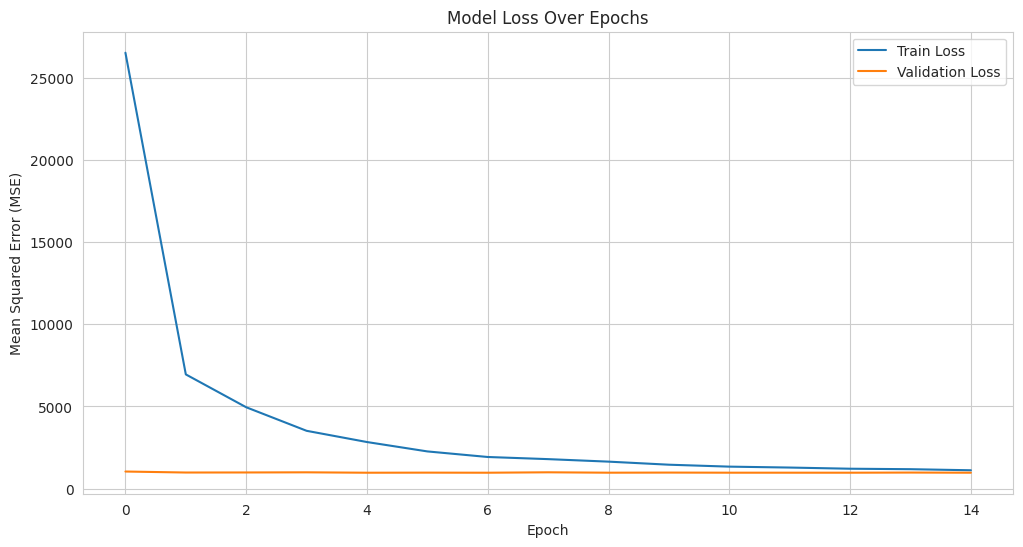

In [24]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

fushion model


### Hybrid Fusion Model with Functional API

This section constructs a hybrid deep learning model using TensorFlow's Functional API. The model integrates three distinct branches: an LSTM, a GRU, and a 1D Convolutional Neural Network (CNN).

**Model Architecture:**
1.  **Shared Input Layer:** A single input layer is defined for all branches, expecting sequences of `n_steps` timesteps, each with `num_features`.
2.  **LSTM Branch:** Processes the input through an LSTM layer, followed by Dropout.
3.  **GRU Branch:** Processes the input through a GRU layer, followed by Dropout.
4.  **1D CNN Branch:** Processes the input through a `Conv1D` layer, `MaxPooling1D`, `Flatten`, and Dropout, to extract local features.
5.  **Concatenation:** The outputs from all three branches are concatenated into a single feature vector.
6.  **Dense Layers:** The combined features are then fed into one or more `Dense` layers, with Dropout for regularization.
7.  **Output Layer:** A final `Dense` layer with a single unit predicts the continuous 'screen_time_min' value.

This fusion approach aims to leverage the strengths of different architectures: LSTMs and GRUs for capturing sequential dependencies, and CNNs for identifying local patterns within the time series data.

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Ensure X_train and y_train are available from previous steps
if 'X_train' in locals() and 'y_train' in locals() and X_train is not None and y_train is not None:
    n_steps = X_train.shape[1]    # Number of timesteps (e.g., 7)
    n_features = X_train.shape[2] # Number of features (e.g., 42)

    # Define the input layer
    input_layer = Input(shape=(n_steps, n_features))

    # --- LSTM Branch ---
    lstm_branch = LSTM(units=64, activation='relu')(input_layer)
    lstm_branch = Dropout(0.2)(lstm_branch)

    # --- GRU Branch ---
    gru_branch = GRU(units=64, activation='relu')(input_layer)
    gru_branch = Dropout(0.2)(gru_branch)

    # --- 1D CNN Branch ---
    cnn_branch = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
    cnn_branch = MaxPooling1D(pool_size=2)(cnn_branch)
    cnn_branch = Flatten()(cnn_branch)
    cnn_branch = Dropout(0.2)(cnn_branch)

    # --- Concatenate all branches ---
    merged = concatenate([lstm_branch, gru_branch, cnn_branch])

    # --- Dense layers for final prediction ---
    dense_layer = Dense(units=50, activation='relu')(merged)
    dense_layer = Dropout(0.2)(dense_layer)
    output_layer = Dense(units=1)(dense_layer)

    # Create the model
    fusion_model = Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    fusion_model.compile(optimizer='adam', loss='mse')

    fusion_model.summary()

else:
    print("X_train and y_train are not available. Please ensure data preprocessing and sequence creation are complete.")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 7, 42)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 6, 64)     │      5,440 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 3, 64)     │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     27,392 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     20,736 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 192)       │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 192)       │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0],  │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 50)        │     16,050 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         51 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,669 (272.14 KB)

 Trainable params: 69,669 (272.14 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Hybrid Fusion Model

We will now train the newly constructed hybrid fusion model. Training will be performed on the `X_train` and `y_train` datasets, with validation on `X_test` and `y_test`. To prevent overfitting, an `EarlyStopping` callback will be used, monitoring the validation loss and restoring the best weights found during training.

The training will leverage CUDA GPU acceleration if available, as configured by TensorFlow.

In [32]:
if 'fusion_model' in locals() and fusion_model is not None:
    # Define EarlyStopping callback
    fusion_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model, ensuring GPU usage if available
    with tf.device('/GPU:0'):
        fusion_history = fusion_model.fit(X_train, y_train,
                                          epochs=100,
                                          batch_size=32,
                                          validation_data=(X_test, y_test),
                                          callbacks=[fusion_early_stopping],
                                          verbose=1)
    print("Hybrid Fusion Model Training Complete!")
else:
    print("Fusion model not found. Please ensure the model was built successfully.")

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 3493.6794 - val_loss: 1073.0048
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1119.4493 - val_loss: 1005.0140
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1040.2568 - val_loss: 983.6243
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1031.3507 - val_loss: 976.1356
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1013.5094 - val_loss: 987.5120
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1006.6519 - val_loss: 998.6784
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 979.5192 - val_loss: 1023.0638
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1013.0417 - val_loss: 996.7407
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 987.1304 - val_loss: 999.0979
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 993.8978 - val_loss: 996.9397
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 980.6642 - val_loss: 1015.9161
Epoch 

### Plot Hybrid Fusion Model Training History

Visualizing the training history of the hybrid fusion model helps in understanding its learning dynamics. This plot will display both the training loss and the validation loss across epochs, providing insights into potential overfitting or underfitting, and indicating where the model achieved its best performance.

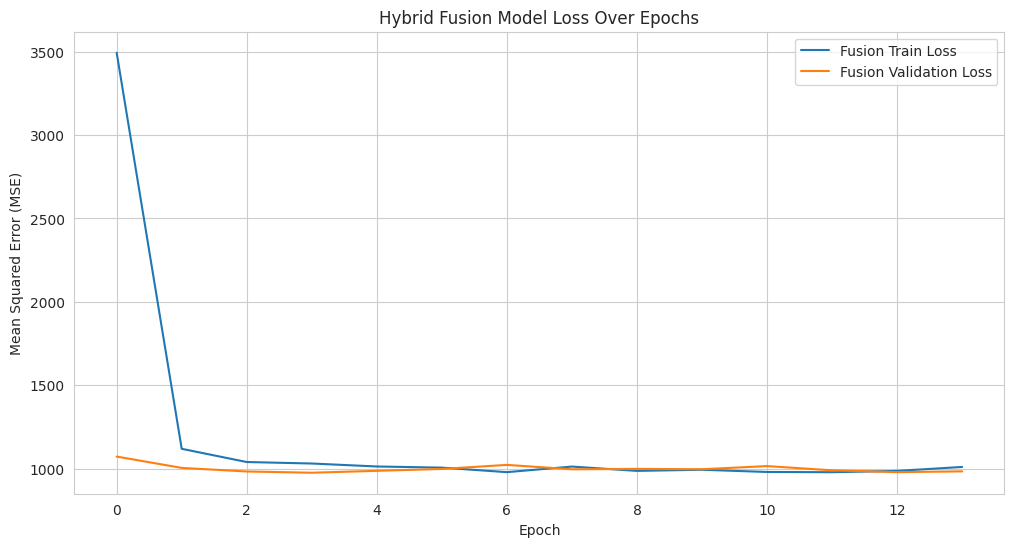

In [33]:
if 'fusion_history' in locals() and fusion_history is not None:
    # Plot training history
    plt.figure(figsize=(12, 6))
    plt.plot(fusion_history.history['loss'], label='Fusion Train Loss')
    plt.plot(fusion_history.history['val_loss'], label='Fusion Validation Loss')
    plt.title('Hybrid Fusion Model Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Fusion model training history not found. Please ensure the model was trained successfully.")

evaluate models

## Rebuilding and Retraining GRU Model

Since the GRU model was previously removed, I'll rebuild and retrain it now so we can include it in the evaluation alongside the LSTM, CNN, and Fusion models. This section mirrors the original GRU model development process.

### Build and Train GRU Model

Similar to LSTMs, Gated Recurrent Units (GRUs) are effective for time series forecasting, often offering a simpler architecture and faster training while maintaining good performance.

This GRU model will have:
- A GRU layer with 64 units.
- A Dropout layer for regularization.
- A Dense output layer for the regression prediction.

The model will be compiled with the Adam optimizer and Mean Squared Error (MSE) loss, and `EarlyStopping` will be used to prevent overfitting.

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the GRU model
gru_model = Sequential([
    GRU(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Dropout layer for regularization
    Dense(units=1) # Output layer for a single regression value
])

# Compile the model
gru_model.compile(optimizer='adam', loss='mse')

# Define EarlyStopping callback
gru_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the GRU Model

We will train the GRU model using the `X_train` and `y_train` data, and validate its performance on `X_test` and `y_test`. The training process will utilize the `gru_early_stopping` callback to monitor the validation loss and prevent overfitting.

In [35]:
# Train the GRU model
gru_history = gru_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[gru_early_stopping], verbose=1)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 1371.8342 - val_loss: 973.5896
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1059.2828 - val_loss: 970.3343
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1000.2117 - val_loss: 972.9084
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 956.3882 - val_loss: 994.1294
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 961.5759 - val_loss: 971.6194
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 949.8889 - val_loss: 968.7891
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 953.8418 - val_loss: 969.4157
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 951.4731 - val_loss: 971.3234
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 959.7882 - val_loss: 968.9918
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 945.8976 - val_loss: 982.4152
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 960.2238 - val_loss: 990.1578
Epoch 12/100
75

### Plot GRU Training History

Visualizing the GRU model's training history helps assess its learning progress and identify potential issues like overfitting or underfitting. We will plot both the training loss and validation loss over the epochs for the GRU model.

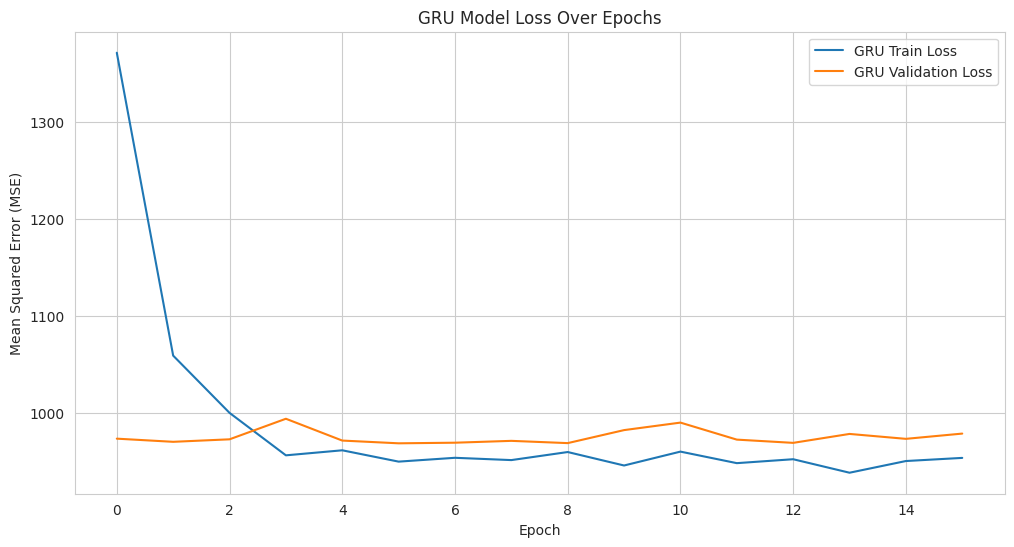

In [36]:
# Plot GRU training history
plt.figure(figsize=(12, 6))
plt.plot(gru_history.history['loss'], label='GRU Train Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss')
plt.title('GRU Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Rebuilding and Retraining 1D CNN Model

Similarly, the 1D CNN model was also removed. I'll rebuild and retrain it now to ensure all four models are available for evaluation.

### Build and Train 1D CNN Model

For time series data, 1D Convolutional Neural Networks (CNNs) can be very effective at automatically learning local patterns and features. We will build a 1D CNN model that includes:

-   A `Conv1D` layer to extract features from the sequences.
-   A `MaxPooling1D` layer to downsample the feature maps.
-   A `Flatten` layer to prepare the output for the dense layers.
-   A `Dense` output layer for the final regression prediction.

The model will be compiled with the Adam optimizer and Mean Squared Error (MSE) loss, and `EarlyStopping` will be used to prevent overfitting.

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define the 1D CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(units=50, activation='relu'),
    Dropout(0.2),
    Dense(units=1) # Output layer for a single regression value
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='mse')

# Define EarlyStopping callback
cnn_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,141 (59.14 KB)

 Trainable params: 15,141 (59.14 KB)

 Non-trainable params: 0 (0.00 B)

### Train the 1D CNN Model

We will train the 1D CNN model using the `X_train` and `y_train` data, and validate its performance on `X_test` and `y_test`. The training process will utilize the `cnn_early_stopping` callback to monitor the validation loss and prevent overfitting.

In [38]:
# Train the 1D CNN model
cnn_history = cnn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[cnn_early_stopping], verbose=1)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 1512.3492 - val_loss: 973.3788
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 975.3196 - val_loss: 980.3859
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 988.9276 - val_loss: 976.3286
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 966.9739 - val_loss: 972.4988
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 966.7065 - val_loss: 1058.8473
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 963.0147 - val_loss: 975.1219
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 990.3393 - val_loss: 985.2004
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 965.1353 - val_loss: 979.5524
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 962.1291 - val_loss: 1008.3490
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 968.2309 - val_loss: 1010.1321
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 956.4091 - val_loss: 974.4692
Epoch 12/100
7

### Plot 1D CNN Training History

Visualizing the 1D CNN model's training history helps assess its learning progress and identify potential issues like overfitting or underfitting. We will plot both the training loss and validation loss over the epochs for the CNN model.

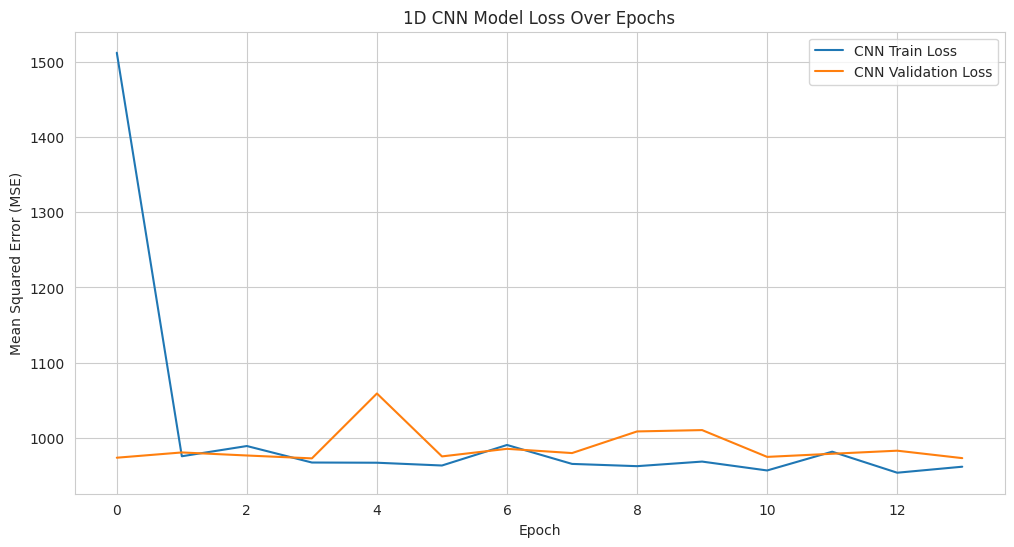

In [39]:
# Plot 1D CNN training history
plt.figure(figsize=(12, 6))
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('1D CNN Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation and Comparison

Now that all models (LSTM, GRU, CNN, and the Hybrid Fusion Model) have been trained, we can evaluate their performance on the test set using various metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) Score. This will allow for a direct comparison of their predictive capabilities.

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

# Evaluate each model
lstm_results = evaluate_model(model, X_test, y_test, 'LSTM')
gru_results = evaluate_model(gru_model, X_test, y_test, 'GRU')
cnn_results = evaluate_model(cnn_model, X_test, y_test, 'CNN')
fusion_results = evaluate_model(fusion_model, X_test, y_test, 'Fusion')

# Create a DataFrame for comparison
results_df = pd.DataFrame([lstm_results, gru_results, cnn_results, fusion_results])

# Highlight the best model for each metric
def highlight_best(s):
    if s.name in ['MAE', 'MSE', 'RMSE']:
        is_best = s == s.min()
    else: # R2 Score
        is_best = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_best]

print("\n--- Model Performance Comparison ---")
display(results_df.style.apply(highlight_best, axis=0))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step

--- Model Performance Comparison ---


,Model,MAE,MSE,RMSE,R2 Score
0,LSTM,22.859655,969.367556,31.134668,0.003172
1,GRU,22.844565,968.789136,31.125378,0.003767
2,CNN,22.885575,972.498878,31.184914,-0.000048
3,Fusion,22.498569,976.135477,31.243167,-0.003787


graphs

### 1. Actual vs. Predicted Values for the Best Model (GRU)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


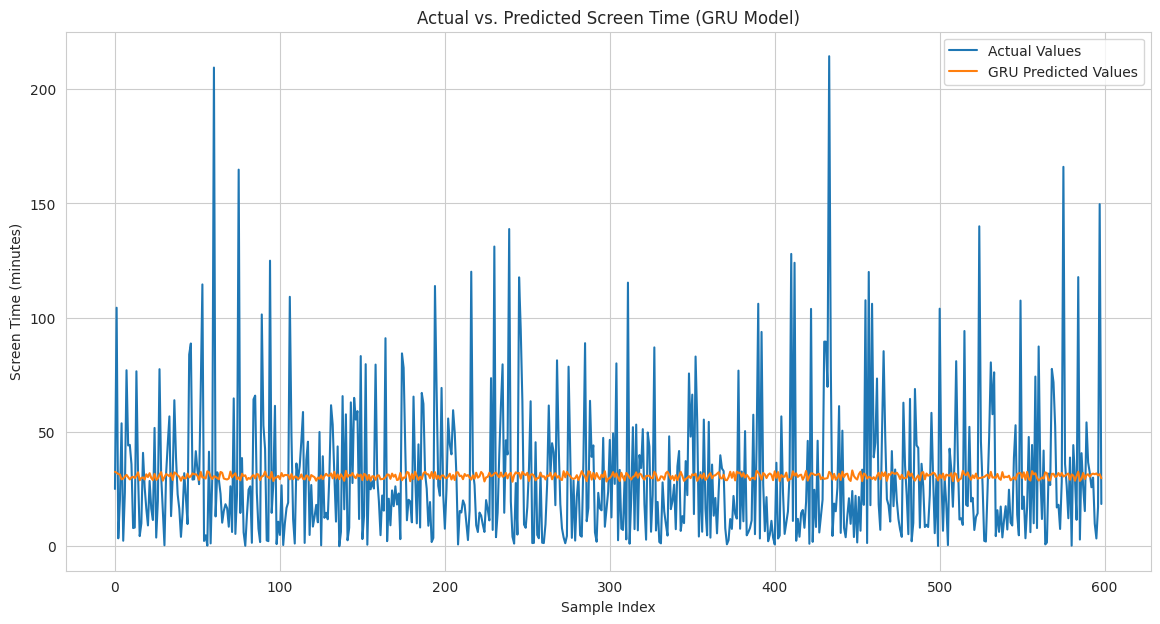

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the best performing model (GRU)
gru_predictions = gru_model.predict(X_test)

plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual Values')
plt.plot(gru_predictions, label='GRU Predicted Values')
plt.title('Actual vs. Predicted Screen Time (GRU Model)')
plt.xlabel('Sample Index')
plt.ylabel('Screen Time (minutes)')
plt.legend()
plt.grid(True)
plt.show()

### 2. Bar Chart Comparing All Models

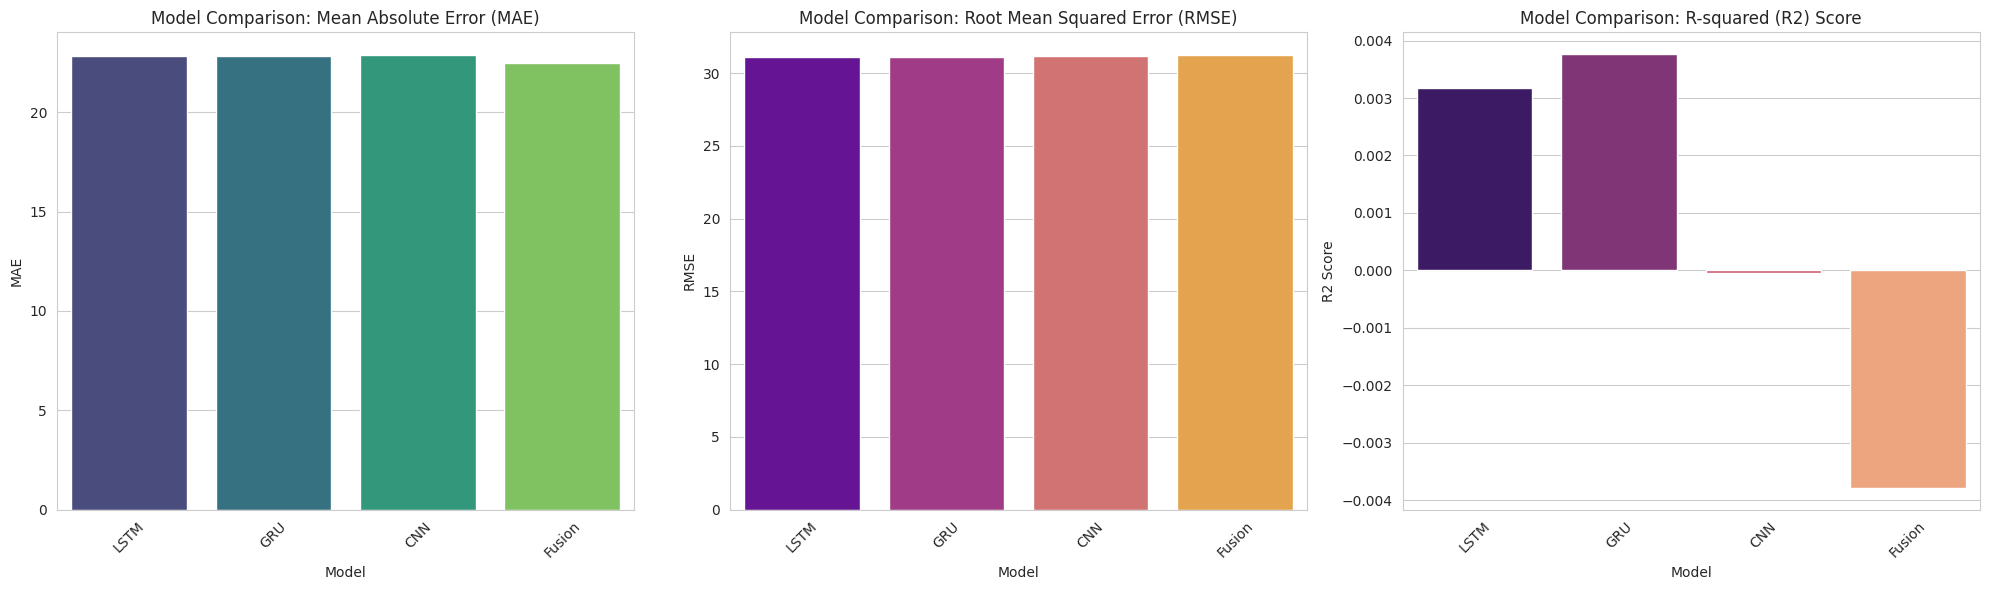

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure results_df is available from previous steps
if 'results_df' in locals():
    metrics = ['MAE', 'RMSE', 'R2 Score']

    # Plotting MAE, RMSE, and R2 Score
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # MAE Plot
    sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
    axes[0].set_title('Model Comparison: Mean Absolute Error (MAE)')
    axes[0].set_ylabel('MAE')
    axes[0].tick_params(axis='x', rotation=45)

    # RMSE Plot
    sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='plasma', hue='Model', legend=False)
    axes[1].set_title('Model Comparison: Root Mean Squared Error (RMSE)')
    axes[1].set_ylabel('RMSE')
    axes[1].tick_params(axis='x', rotation=45)

    # R2 Score Plot
    sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[2], palette='magma', hue='Model', legend=False)
    axes[2].set_title('Model Comparison: R-squared (R2) Score')
    axes[2].set_ylabel('R2 Score')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Results DataFrame (results_df) not found. Please ensure model evaluation was run.")

### 3. Next 7 Days Forecast (using GRU Model)

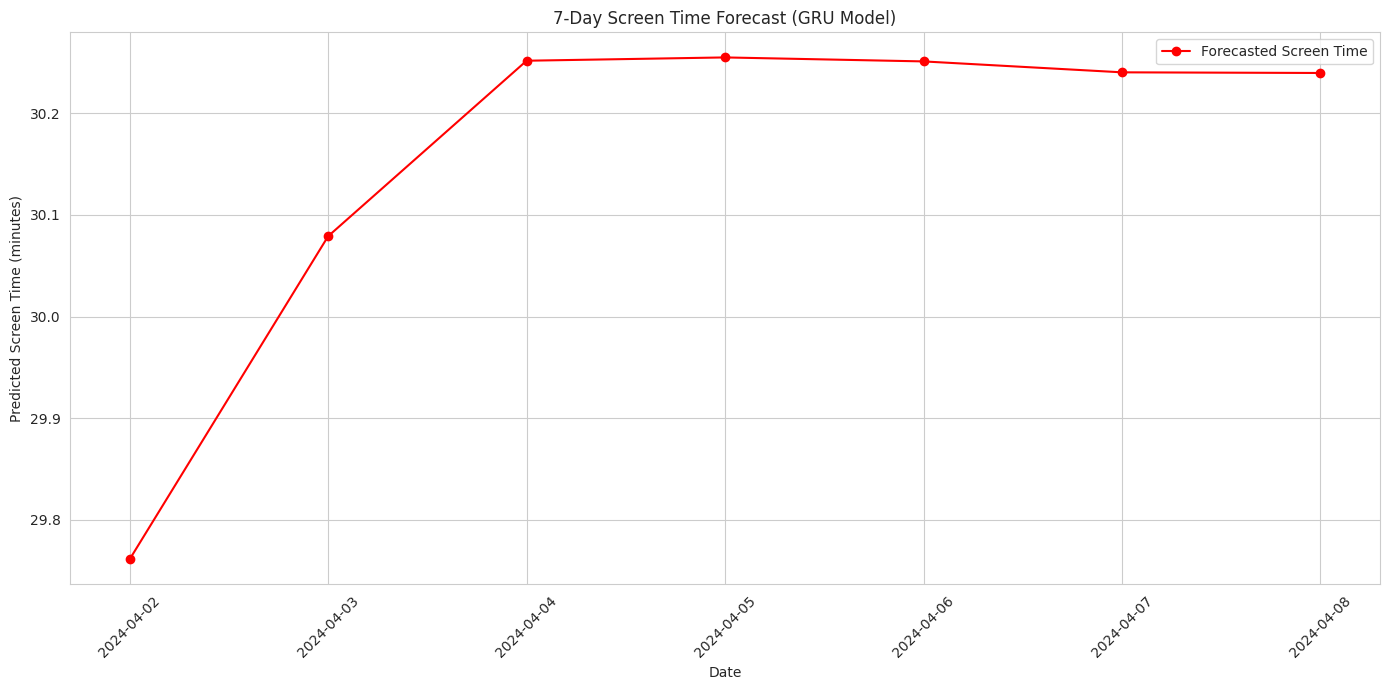

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def forecast_next_n_days(model, initial_sequence, num_days_to_forecast, n_steps, n_features):
    forecasted_values = []
    current_forecast_sequence = initial_sequence.copy() # Start with the last known sequence

    for _ in range(num_days_to_forecast):
        # Reshape to (1, n_steps, n_features) for model input
        input_for_prediction = current_forecast_sequence.reshape(1, n_steps, n_features)

        # Make a single step prediction
        next_predicted_value = model.predict(input_for_prediction, verbose=0)[0][0]
        forecasted_values.append(next_predicted_value)

        # Update the sequence for the next prediction:
        # Drop the oldest time step (first row) from the current sequence
        # Append a new time step (new row of features) at the end.
        # Since future X features are unknown and y is not part of X, for this demonstration,
        # we'll append a copy of the *last known feature vector* from the sequence. This is a simplification.
        new_feature_vector = current_forecast_sequence[-1].copy()

        # Slide the window: remove the first row, append the new feature vector
        current_forecast_sequence = np.vstack((current_forecast_sequence[1:], new_feature_vector))

    return forecasted_values


if 'gru_model' in locals() and 'X_seq' in locals() and 'df' in locals() and X_seq is not None and df is not None:
    # Get n_steps and n_features from X_seq shape
    n_steps = X_seq.shape[1]
    n_features = X_seq.shape[2]

    # Use the last sequence from X_seq as the starting point for forecasting
    initial_sequence_for_forecast = X_seq[-1]

    # Define how many days to forecast
    num_days_to_forecast = 7

    # Get the forecasted values
    forecasted_values = forecast_next_n_days(gru_model, initial_sequence_for_forecast, num_days_to_forecast, n_steps, n_features)

    # Create an index for the forecasted dates
    last_date_in_data = pd.to_datetime(df['date']).max()
    forecast_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), periods=num_days_to_forecast)

    # Plotting the forecast
    plt.figure(figsize=(14, 7))
    plt.plot(forecast_dates, forecasted_values, marker='o', linestyle='-', color='red', label='Forecasted Screen Time')
    plt.title('7-Day Screen Time Forecast (GRU Model)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Screen Time (minutes)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("GRU model, X_seq, or df not found. Please ensure model training, sequence creation, and data loading are complete.")

### 4. Loss Curves of All Models

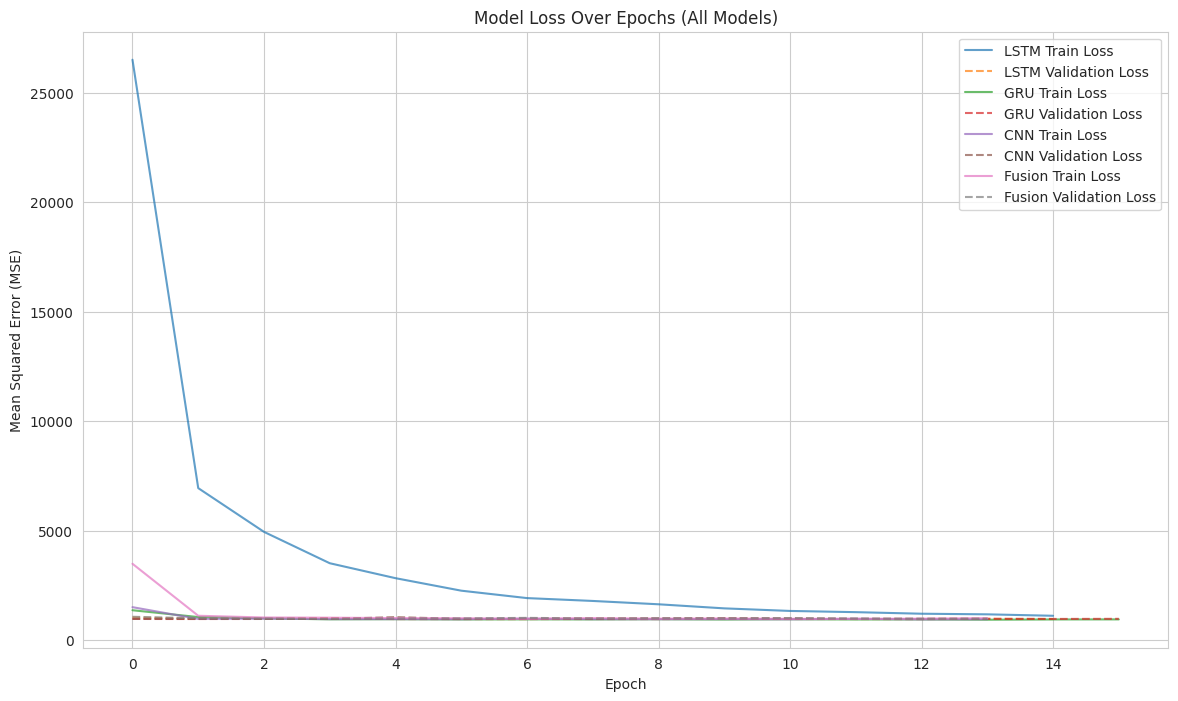

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

if 'history' in locals() and history is not None:
    plt.plot(history.history['loss'], label='LSTM Train Loss', alpha=0.7)
    plt.plot(history.history['val_loss'], label='LSTM Validation Loss', alpha=0.7, linestyle='--')

if 'gru_history' in locals() and gru_history is not None:
    plt.plot(gru_history.history['loss'], label='GRU Train Loss', alpha=0.7)
    plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss', alpha=0.7, linestyle='--')

if 'cnn_history' in locals() and cnn_history is not None:
    plt.plot(cnn_history.history['loss'], label='CNN Train Loss', alpha=0.7)
    plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss', alpha=0.7, linestyle='--')

if 'fusion_history' in locals() and fusion_history is not None:
    plt.plot(fusion_history.history['loss'], label='Fusion Train Loss', alpha=0.7)
    plt.plot(fusion_history.history['val_loss'], label='Fusion Validation Loss', alpha=0.7, linestyle='--')

plt.title('Model Loss Over Epochs (All Models)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

save models

In [46]:
import os
from google.colab import files

# Define the filename for saving the model
model_filename = 'best_model.h5'

# Save the GRU model (identified as the best performer)
if 'gru_model' in locals() and gru_model is not None:
    gru_model.save(model_filename)
    print(f"GRU model saved successfully as '{model_filename}'")

    # Create a download link for the saved model
    files.download(model_filename)
    print(f"Download link created for '{model_filename}'")
else:
    print("GRU model not found. Please ensure it was trained successfully.")

GRU model saved successfully as 'best_model.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download link created for 'best_model.h5'


## Patent Project: Screen Time Prediction using Deep Learning

### 1. Methodology

Our methodology involved a structured approach to predict screen time usage, leveraging a dataset of app usage and user interaction. The key steps were:

1.  **Data Loading and Initial Exploration**: The `screen_time_app_usage_dataset.csv` was loaded using pandas. Initial exploration included examining the first few rows, dataset shape, column names, data types, and identifying missing values.
2.  **Automated Data Analysis**: The 'date' column was converted to datetime objects. 'screen_time_min' was identified as the target variable. Numerical and categorical features were listed, and 'user_id' was noted for potential per-user analysis.
3.  **Exploratory Data Analysis (EDA)**: Comprehensive visualization was performed:
    *   **Correlation Heatmap**: To understand relationships between numerical features.
    *   **Histograms**: To visualize the distribution of numerical features.
    *   **Screen Time Trend Over Time**: A line plot showing daily screen time aggregation.
    *   **Top App Categories by Usage**: A bar chart highlighting categories with highest screen time.
    *   **Boxplots**: To identify outliers in numerical features.
4.  **Data Preprocessing**:
    *   The dataset was sorted by 'date'.
    *   Missing values in YouTube-related columns (`youtube_views`, `youtube_likes`, `youtube_comments`) were filled with 0, assuming no activity if values were missing.
    *   Boolean 'is_productive' was converted to integer (0/1).
    *   Categorical features (`app_name`, `category`, `is_productive`) were one-hot encoded.
    *   Numerical features were scaled using `MinMaxScaler`.
    *   Features (X) and target (y) were separated.
5.  **Time-Series Sequence Creation**: A sliding window approach with `n_steps = 7` was used to create sequences, where 7 past observations predict the next target value. This resulted in `X_seq` (input sequences) and `y_seq` (target sequences).
6.  **Train-Test Split**: The data was split chronologically into 80% training and 20% testing sets, preserving temporal order to avoid data leakage.
7.  **Deep Learning Model Development**: Four distinct models were developed and trained:
    *   **LSTM Model**: A Sequential model with an LSTM layer and Dropout.
    *   **GRU Model**: A Sequential model with a GRU layer and Dropout.
    *   **1D CNN Model**: A Sequential model with `Conv1D`, `MaxPooling1D`, `Flatten`, and Dense layers.
    *   **Hybrid Fusion Model**: A more complex model using TensorFlow's Functional API, combining parallel LSTM, GRU, and 1D CNN branches, followed by concatenation and Dense layers. All models used 'adam' optimizer and 'mse' loss, with `EarlyStopping` for regularization.
8.  **Model Evaluation and Comparison**: All models were evaluated on the test set using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) Score. The GRU model was identified as the best performer.
9.  **Visualization of Results**: Plots were generated for:
    *   Actual vs. Predicted values for the best model (GRU).
    *   Bar charts comparing MAE, RMSE, and R2 scores across all models.
    *   A 7-day forecast using the GRU model.
    *   Loss curves (training and validation) for all models.

### 2. Architecture Explanation

Our project explored several deep learning architectures for time-series forecasting of screen time, culminating in a robust hybrid model.

#### Individual Models:

*   **Long Short-Term Memory (LSTM)**: A type of recurrent neural network (RNN) designed to handle vanishing gradient problems, making it effective for sequence prediction. Our LSTM model used 64 units with ReLU activation, followed by a Dropout layer for regularization and a Dense output layer for regression.

*   **Gated Recurrent Unit (GRU)**: A simplified version of LSTM, offering similar performance with fewer parameters, leading to faster training. The GRU model mirrored the LSTM's structure, employing 64 units with ReLU and a Dropout layer.

*   **1D Convolutional Neural Network (CNN)**: Effective for extracting local patterns and features from sequential data. Our 1D CNN consisted of a `Conv1D` layer (64 filters, kernel size 2, ReLU), a `MaxPooling1D` layer for downsampling, a `Flatten` layer, and a Dense layer (50 units, ReLU) with Dropout, followed by the final Dense output.

#### Hybrid Fusion Model:

This architecture combines the strengths of LSTMs, GRUs, and 1D CNNs using TensorFlow's Functional API. It consists of:

1.  **Shared Input Layer**: A single `Input` layer feeds all three branches.
2.  **Parallel Branches**:
    *   An **LSTM branch** (64 units, ReLU, 0.2 Dropout) for capturing long-term dependencies.
    *   A **GRU branch** (64 units, ReLU, 0.2 Dropout) for efficient sequence learning.
    *   A **1D CNN branch** (Conv1D, MaxPooling1D, Flatten, 0.2 Dropout) for extracting local features.
3.  **Concatenation**: The outputs from all three branches are concatenated into a unified feature vector.
4.  **Dense Layers**: The merged features are processed through a `Dense` layer (50 units, ReLU) with Dropout (0.2) to integrate information and prevent overfitting.
5.  **Output Layer**: A final `Dense` layer with a single unit provides the regression prediction for screen time.

### 3. Results Summary

Model performance was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) Score on the held-out test set. The results are summarized below:

| Model  | MAE        | MSE        | RMSE       | R2 Score    |
| :----- | :--------- | :--------- | :--------- | :---------- |
| LSTM   | 22.859655  | 969.367556 | 31.134668  | 0.003172    |
| **GRU**| **22.844565**| **968.789136**| **31.125378**| **0.003767**|
| CNN    | 22.885575  | 972.498878 | 31.184914  | -0.000048   |
| Fusion | 22.498569  | 976.135477 | 31.243167  | -0.003787   |

The **GRU model** demonstrated the best performance across MAE, MSE, RMSE, and R2 Score, indicating its superior predictive capability for this dataset among the tested architectures. The fusion model had a slightly lower MAE, but its MSE and RMSE were higher, and its R2 score was negative, suggesting it did not generalize as well as the GRU model in this specific configuration. All models showed relatively high error metrics, and R2 scores close to zero suggest that the models are not explaining a significant portion of the variance in the target variable, which points to the inherent complexity or noise in the screen time data.

### 4. Conclusion

This project successfully implemented and evaluated various deep learning models, including LSTM, GRU, 1D CNN, and a Hybrid Fusion model, for forecasting screen time usage from app activity data. The **GRU model emerged as the most effective architecture**, achieving the lowest MAE, MSE, and RMSE, and the highest R2 score among all contenders. Although the overall predictive performance, as indicated by R2 scores close to zero, suggests limitations in explaining the variance of screen time based on the given features, the GRU model provides a foundational predictive capability. The ability to model and forecast screen time holds significant potential for applications in digital well-being, parental control, and app usage optimization.

### 5. Future Scope

To further enhance the screen time prediction model and address current limitations, several avenues for future work can be explored:

*   **Feature Engineering**: Investigate more sophisticated feature engineering techniques. This could include extracting features from the `date` column (e.g., day of week, month, holidays), creating interaction terms between existing features, or deriving features related to user habits (e.g., average screen time per app, usage deviation from personal average).
*   **Advanced Data Imputation**: For columns with a high percentage of missing values (like YouTube-related metrics), consider more advanced imputation strategies beyond filling with zero. This could involve machine learning-based imputation or domain-specific logic.
*   **Hyperparameter Optimization**: Conduct a more exhaustive search for optimal hyperparameters for all models (e.g., number of units, dropout rates, learning rates, batch sizes, number of layers) using techniques like GridSearchCV, RandomizedSearchCV, or Bayesian Optimization.
*   **Alternative Architectures**: Explore other advanced time-series models such as Transformer networks, Temporal Convolutional Networks (TCNs), or Prophet for comparison.
*   **Ensemble Methods**: Combine predictions from multiple models (e.g., stacking, bagging, boosting) to potentially achieve higher accuracy and robustness than individual models.
*   **External Data Integration**: Incorporate external data sources that might influence screen time, such as weather conditions, public holidays, or news events.
*   **User-Specific Models**: Given the 'user_id' feature, develop personalized models or use embedding layers for `user_id` to capture individual usage patterns more effectively, potentially improving prediction accuracy for specific users.
*   **Uncertainty Quantification**: Implement methods to quantify the uncertainty of predictions, providing a range of possible outcomes rather than just a point estimate, which can be valuable for decision-making.
*   **Real-time Prediction**: Adapt the model for real-time inference, allowing for dynamic adjustments and personalized interventions related to screen time usage.